In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import DiffQ as DQ

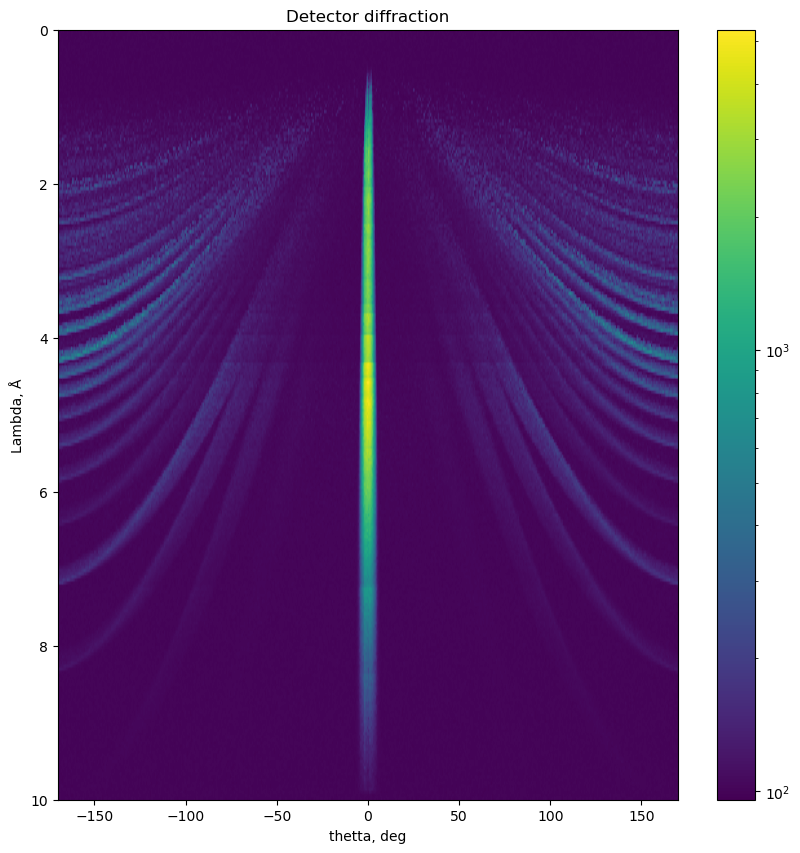

In [28]:
# test crystals - C_graphite Na2Ca3Al2F14

crystal = 'Na2Ca3Al2F14'

diffraction = np.load('Na2Ca3Al2F14_test_diffraction_numpy.npy')

plt.figure(figsize=(10, 10))
plt.imshow(diffraction, cmap='viridis', aspect='auto', norm = 'log', extent=(-170, 170, 10, 0))
plt.title("Detector diffraction")
#plt.axis('off')
plt.xlabel('thetta, deg')
plt.ylabel('Lambda, Å')
plt.colorbar()
plt.show()

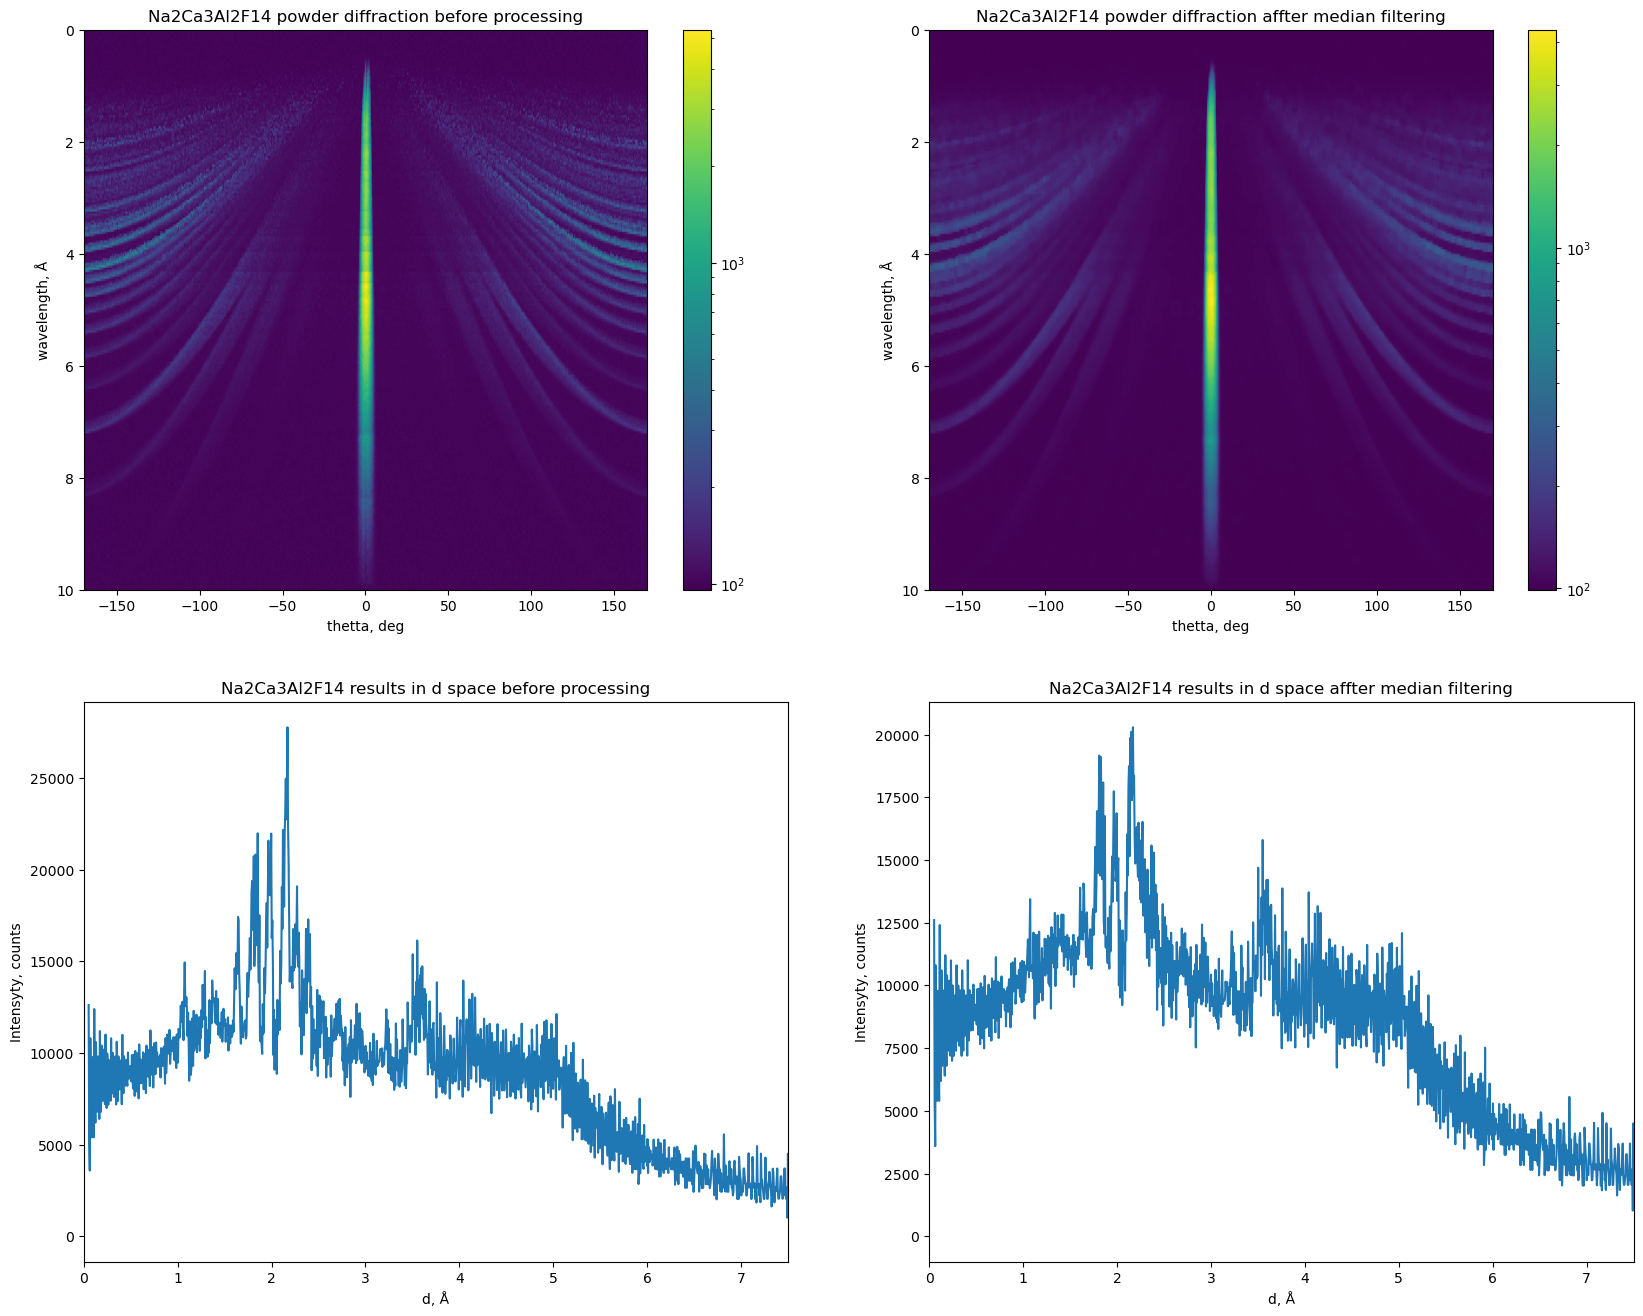

In [30]:
from scipy.ndimage import median_filter


# Применяем медианный фильтр с размером окна 3x3
filtered_image = median_filter(diffraction, size=5)

Qplotter_low_res = DQ.Qwrapper(480, 250)
ADC_chanales = 45000
q1, I1 = Qplotter_low_res.getQDIFADC(diffraction, 6 * ADC_chanales)
q2, I2 = Qplotter_low_res.getQDIFADC(filtered_image, 6 * ADC_chanales)

# Создаем фигуру и оси
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
ax1, ax2 = axes[0]  # Первая строка осей
ax3, ax4 = axes[1]  # Вторая строка осей

im1 = ax1.imshow(diffraction, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax1.set_title(f'{crystal} powder diffraсtion before processing')
ax1.set_ylabel('wavelength, Å')
ax1.set_xlabel('thetta, deg')
plt.colorbar(im1)

im2 = ax2.imshow(filtered_image, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax2.set_title(f'{crystal} powder diffraсtion affter median filtering')
ax2.set_ylabel('wavelength, Å')
ax2.set_xlabel('thetta, deg')
plt.colorbar(im2)

ax3.plot(q1, I1)
#ax3.set_yscale('log')
ax3.set_xlim(0,7.5)
ax3.set_title(f'{crystal} results in d space before processing')
ax3.set_xlabel('d, Å')
ax3.set_ylabel('Intensyty, counts')

ax4.plot(q2, I2)
#ax4.set_yscale('log')
ax4.set_xlim(0,7.5)
ax4.set_title(f'{crystal} results in d space affter median filtering')
ax4.set_xlabel('d, Å')
ax4.set_ylabel('Intensyty, counts')

plt.show()

In [31]:
from bm3d import bm3d

# --- Нормализация в [0,1] ---
img_min = diffraction.min()
img_max = diffraction.max()
image_norm = (diffraction - img_min) / (img_max - img_min)

# --- Задаём шум (например если не знаем точно) ---
#sigma_bm3d = 0.02

# Шум можно оценить по фону дифракции как
sigma_bm3d = 100 / (img_max - img_min)
print(sigma_bm3d)

# --- Применяем BM3D ---
denoised_norm = bm3d(image_norm, sigma_psd=sigma_bm3d)

# --- Возвращаем в оригинальный диапазон ---
denoised = denoised_norm * (img_max - img_min) + img_min

0.01916802409796359


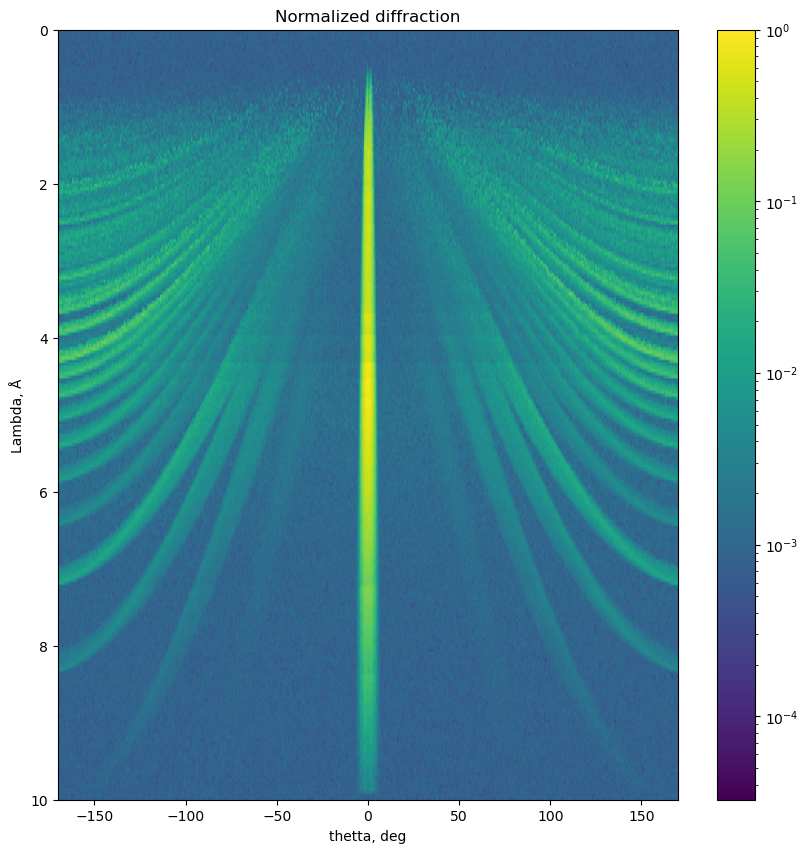

In [32]:
plt.figure(figsize=(10, 10))
plt.imshow(image_norm, cmap='viridis', aspect='auto', norm = 'log', extent=(-170, 170, 10, 0))
plt.title("Normalized diffraction")
#plt.axis('off')
plt.xlabel('thetta, deg')
plt.ylabel('Lambda, Å')
plt.colorbar()
plt.show()

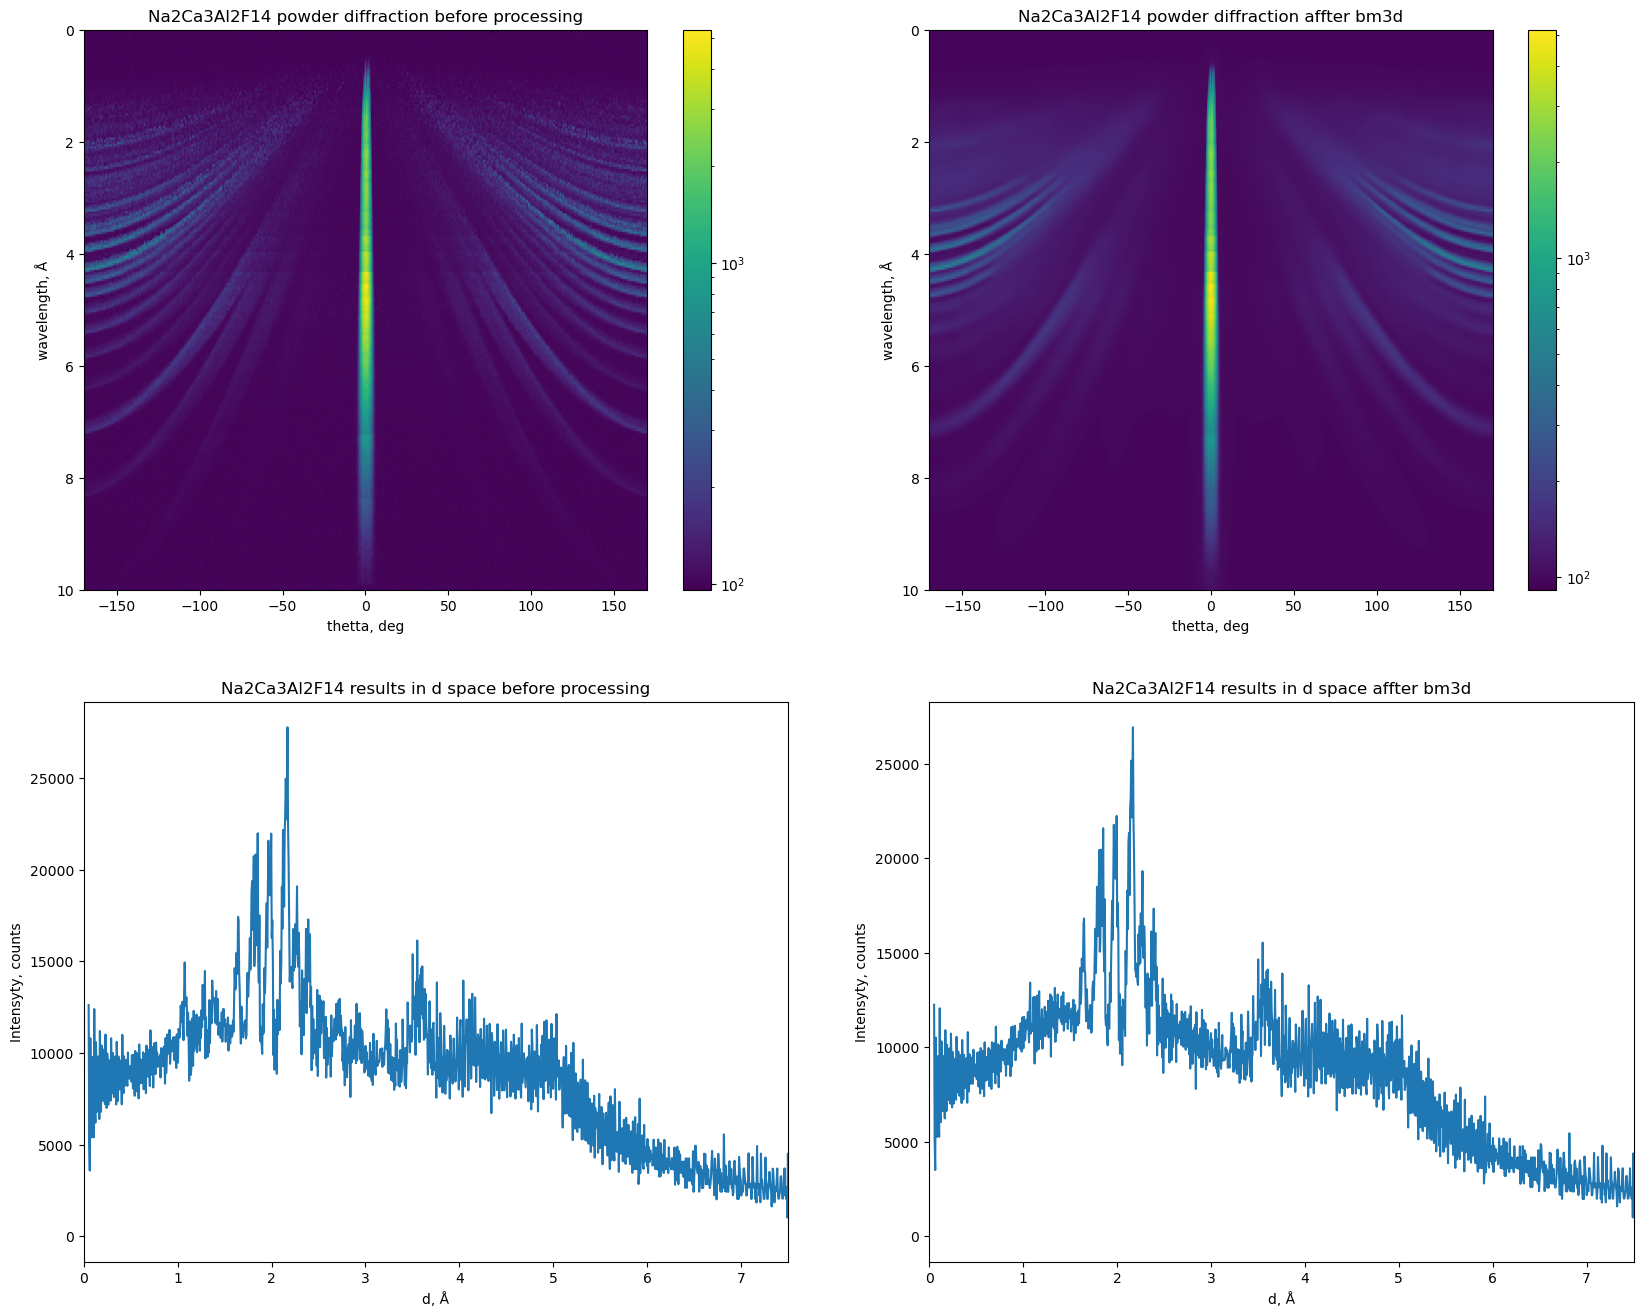

In [33]:
Qplotter_low_res = DQ.Qwrapper(480, 250)
ADC_chanales = 45000
q1, I1 = Qplotter_low_res.getQDIFADC(diffraction, 6 * ADC_chanales)
q2, I2 = Qplotter_low_res.getQDIFADC(denoised, 6 * ADC_chanales)

# Создаем фигуру и оси
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
ax1, ax2 = axes[0]  # Первая строка осей
ax3, ax4 = axes[1]  # Вторая строка осей

im1 = ax1.imshow(diffraction, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax1.set_title(f'{crystal} powder diffraсtion before processing')
ax1.set_ylabel('wavelength, Å')
ax1.set_xlabel('thetta, deg')
plt.colorbar(im1)

im2 = ax2.imshow(denoised, cmap='viridis', aspect='auto', norm='log', extent=(-170, 170, 10, 0))
ax2.set_title(f'{crystal} powder diffraсtion affter bm3d')
ax2.set_ylabel('wavelength, Å')
ax2.set_xlabel('thetta, deg')
plt.colorbar(im2)

ax3.plot(q1, I1)
#ax3.set_yscale('log')
ax3.set_xlim(0,7.5)
ax3.set_title(f'{crystal} results in d space before processing')
ax3.set_xlabel('d, Å')
ax3.set_ylabel('Intensyty, counts')

ax4.plot(q2, I2)
#ax4.set_yscale('log')
ax4.set_xlim(0,7.5)
ax4.set_title(f'{crystal} results in d space affter bm3d')
ax4.set_xlabel('d, Å')
ax4.set_ylabel('Intensyty, counts')

plt.show()